### <font color=Blue> This notebook demonstrates advanced prompting techniques

In **conventional/standard prompting**, the model generates responses based on it's training for the given prompt.

Conversely, **chain-of-thought prompting** involves directing the model to break down intricate problems into smaller components, presenting both the intermediate logical steps and the ultimate solution.

**Self Consistency** - Generates multiple reasoning paths (via sampling, not greedy decoding), then take a majority vote on the final answers.

    Filter out incorrect or inconsistent reasoning paths and arrive at a more reliable answer.

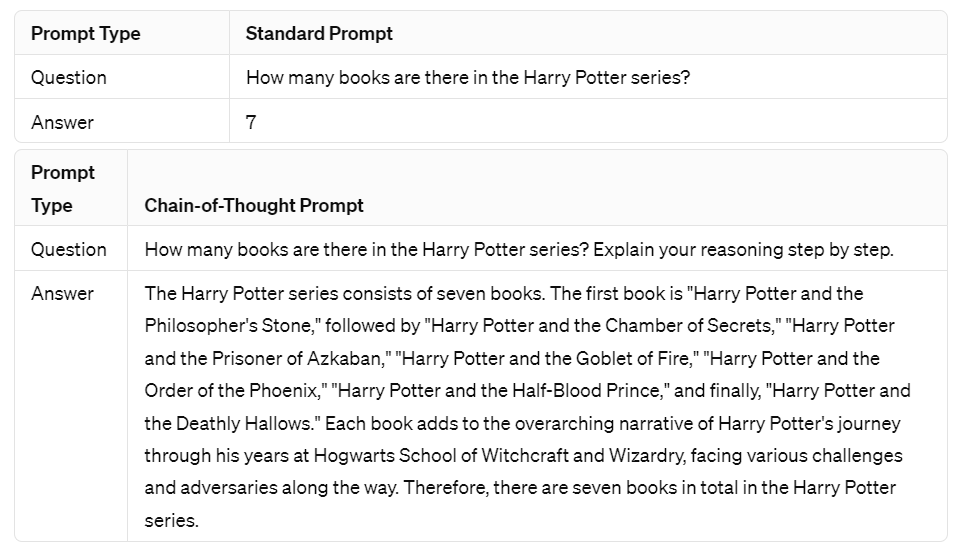

#### Self-consistency aims "to replace the naive greedy decoding used in chain-of-thought prompting" as proposed by Wang et al. in 2022.
[ [2203.11171] Self-Consistency Improves Chain of Thought Reasoning in Language Models (arxiv.org)]. 

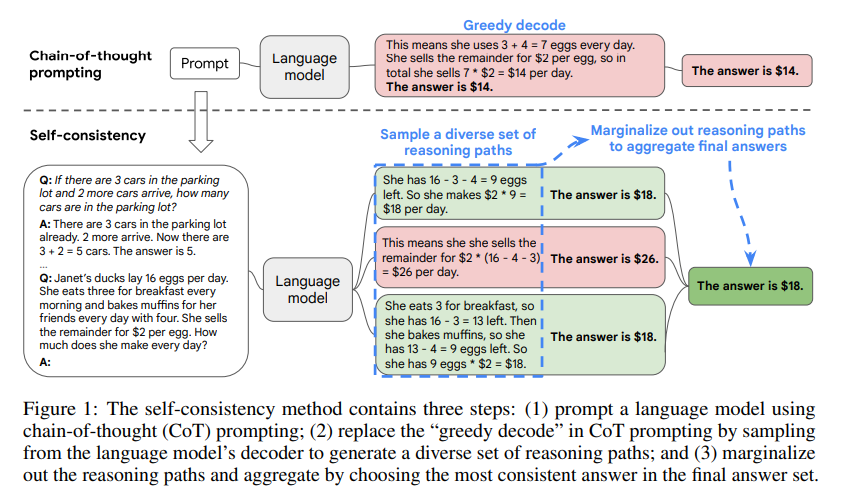

Credits: [ [2203.11171] Self-Consistency Improves Chain of Thought Reasoning in Language Models (arxiv.org)]. 

### <font color=Blue> Example 1 : Standard \Zero-shot Prompting

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
from langchain_aws import ChatBedrockConverse
llm=ChatBedrockConverse(model='amazon.nova-lite-v1:0',
                       aws_access_key_id='',
                       aws_secret_access_key='',
                       region_name='us-east-1',max_tokens=200)
llm.invoke("Hi").content

"Hello! How can I assist you today? If you have any questions or need help with something, feel free to let me know. Whether it's information, advice, or just a friendly chat, I'm here to help."

In [2]:
question = "Ion Henry made two stops during his 60-mile bike trip. He first stopped after 20\
miles. His second stop was 15 miles before the end of the trip. How many miles\
did he travel between his first and second stops?"

In [4]:
llm.invoke(question).content

"Between his first and second stops, Ion Henry traveled a total of 25 miles. \n\nTo calculate the distance, we can use the information given: \n1. Ion Henry's first stop: 20 miles\n2. The second stop was 15 miles before the end of the trip, which means he had 15 miles remaining after the second stop. \n\nSo, to find the distance between the first and second stops: \n20 miles (first stop) + Distance between stops = 15 miles (remaining after the second stop) \n\nNow, let's calculate the distance between the stops: \n20 miles + Distance between stops = 15 miles \n\nDistance between stops = 15 miles - 20 miles \nDistance between stops = 5 miles \n\nSo, Ion Henry traveled 5 miles between his first and second stops."

##  <font color=Blue>Example 2: Zero-shot Learning COT

In [3]:
from langchain_core.prompts import PromptTemplate

In [4]:
template = """Question: {question} Answer: Let's think step by step."""

prompt = PromptTemplate(template=template, input_variables=["question"])

In [8]:
llm_chain = prompt | llm

question = "ion Henry made two stops during his 60-mile bike trip. He first stopped after 20\
miles. His second stop was 15 miles before the end of the trip. How many miles\
did he travel between his first and second stops?" 

print(llm_chain.invoke(question).content)

Between his first and second stops, Leon Henry traveled 20 miles + 15 miles = 35 miles.


## <font color=Blue>Example 3: Few-shot Learning COT

The **FewShotPromptTemplate** is designed to create a prompt that includes a few examples followed by a new input question. Here's a breakdown:

    examples=examples_1: A list of example question-answer pairs.
    
    example_prompt: The template for formatting each example.
    
    suffix="Question: {input}": A string that defines how the new input question should be formatted.
    
    input_variables=["input"]: The variable for the new input question.
    
    When used, this template will combine formatted examples with the new question, providing a context for generating a response.

In [20]:
examples = [
  {
    "question": "There are 15 trees in the grove. Grove workers will plant trees in the grove today. \
    After they are done, there will be 21 trees. How many trees did the grove workers plant today?",
    "answer": """
We start with 15 trees. Later we have 21 trees. The difference must be the number of trees they planted.
So, they must have planted 21 - 15 = 6 trees. The answer is 6.
"""
  },
  { "question": "If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?",
    "answer": """ There are 3 cars in the parking lot already. 2 more arrive. Now there are 3 + 2 = 5 cars. The answer is 5."""
  },
  {
    "question": "Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he have now?",
    "answer":""" He has 5 toys. He got 2 from mom, so after that he has 5 + 2 = 7 toys. Then he got 2 more from dad, so
in total he has 7 + 2 = 9 toys. The answer is 9."""
  },
  {
   "question":"Olivia has $23. She bought five bagels for $3 each. How much money does she have left?",
   "answer" : """ She bought 5 bagels for $3 each. This means she spent 5"""
  }
]


In [21]:
example_prompt = PromptTemplate(input_variables=["question", "answer"], template="Question: {question}\n{answer}")

print(example_prompt.format(**examples[2]))

Question: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he have now?
 He has 5 toys. He got 2 from mom, so after that he has 5 + 2 = 7 toys. Then he got 2 more from dad, so
in total he has 7 + 2 = 9 toys. The answer is 9.


In [22]:
from langchain_core.prompts import FewShotPromptTemplate
#Fewshot prompt template
prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    suffix="Question: {input}",
    input_variables=["input"]
)

In [13]:
question = " my sister is half my age when I was 6. Now I’m 70. how old is my sister?"

In [14]:
llm_chain = prompt | llm

print(llm_chain.invoke(question).content)

To determine the age of your sister, let's break down the problem step by step.

1. Determine the age difference between you and your sister.
   - When you were 6 years old, your sister was half your age. So, she was \( \frac{6}{2} = 3 \) years old.
   - This means the age difference between you and your sister is \( 6 - 3 = 3 \) years.

2. Use the age difference to find your sister's current age.
   - Since you are now 70 years old and the age difference is 3 years, your sister is \( 70 - 3 = 67 \) years old.

Therefore, your sister is \(\boxed{67}\) years old.


In [15]:
question = """ Janet's ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes\ 
muffins for her friends every day with four. She sells the remainder at the farmers'\
market daily for $2 per fresh duck egg. How much in dollars does she make every day at the\ 
farmers' market? """

In [16]:
print(llm_chain.invoke(question).content)

Janet's ducks lay 16 eggs per day. From these:

- She eats 3 eggs for breakfast.
- She uses 4 eggs for baking muffins.

So, the total number of eggs used by Janet daily is:
\[ 3 + 4 = 7 \]

Thus, the number of eggs remaining for sale at the farmers' market is:
\[ 16 - 7 = 9 \]

Janet sells each egg at the farmers' market for $2. Therefore, the total amount of money she makes daily from selling the eggs is:
\[ 9 \times 2 = 18 \]

Thus, Janet makes \(\boxed{18}\) dollars every day at the farmers' market.


In [17]:
question = "Ion Henry made two stops during his 60-mile bike trip. He first stopped after 20\
miles. His second stop was 15 miles before the end of the trip. How many miles\
did he travel between his first and second stops?"

In [18]:
print(llm_chain.invoke(question).content)

Ion Henry's first stop was after 20 miles, so he had 60 - 20 = 40 miles left to travel.
His second stop was 15 miles before the end of the trip, so he had 40 - 15 = 25 miles left to travel between his first and second stops.
Therefore, Ion Henry traveled 25 miles between his first and second stops.


## <font color=Blue><b> Example 4: Self Consistency COT

#### Generate multiple reasoning paths (via sampling, not greedy decoding), then take a majority vote on the final answers.

#### Filter out incorrect or inconsistent reasoning paths and arrive at a more reliable answer.

In [23]:
import getpass
import os
from langchain_core.prompts import FewShotPromptTemplate
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from collections import Counter
import re

In [24]:
#### Create LLM Instance
from langchain_aws import ChatBedrockConverse
llm1=ChatBedrockConverse(model= "anthropic.claude-3-sonnet-20240229-v1:0",  #'cohere.command-r-plus-v1:0', #amazon.nova-lite-v1:0
                       aws_access_key_id='',
                       aws_secret_access_key='',
                       region_name='us-east-1',max_tokens=200)
llm1.invoke("Hi").content

'Hello!'

In [25]:
#  Few-shot examples
examples_1 = [
    {
        "question": "Which AI model passed the US Bar Exam in 2023?",
        "answer": """
Are follow up questions needed here: No.
So the final answer is: GPT-4
"""
    },
    {
        "question": "Which company created the first humanoid robot to work in a warehouse in 2023?",
        "answer": """
Are follow up questions needed here: No.
So the final answer is: Figure AI
"""
    },

    {
        "question": "Which LLM was released by Meta in 2023?",
        "answer": """
Are follow up questions needed here: No.
So the final answer is: LLaMA 2
"""
    },
    {
        "question": "Which country approved Bitcoin as legal tender after El Salvador?",
        "answer": """
Are follow up questions needed here: No.
So the final answer is: Central African Republic
"""
    }
]

In [26]:
# Define prompt template
example_prompt = PromptTemplate(
    input_variables=["question"],
    template="Question: {question}\n Answer: {answer}"
)

few_shot_prompt = FewShotPromptTemplate(
    examples=examples_1,
    example_prompt=example_prompt,
    prefix="Answer the questions with reasoning steps: use examples as a template to answer. ",
    suffix="Question: {input}\n Answer:",
    input_variables=["input"],
)


In [27]:
few_shot_prompt

FewShotPromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, examples=[{'question': 'Which AI model passed the US Bar Exam in 2023?', 'answer': '\nAre follow up questions needed here: No.\nSo the final answer is: GPT-4\n'}, {'question': 'Which company created the first humanoid robot to work in a warehouse in 2023?', 'answer': '\nAre follow up questions needed here: No.\nSo the final answer is: Figure AI\n'}, {'question': 'Which LLM was released by Meta in 2023?', 'answer': '\nAre follow up questions needed here: No.\nSo the final answer is: LLaMA 2\n'}, {'question': 'Which country approved Bitcoin as legal tender after El Salvador?', 'answer': '\nAre follow up questions needed here: No.\nSo the final answer is: Central African Republic\n'}], example_prompt=PromptTemplate(input_variables=['answer', 'question'], input_types={}, partial_variables={}, template='Question: {question}\n Answer: {answer}'), suffix='Question: {input}\n Answer:', prefix='Answer the que

In [28]:
# Create chain with output parser

chain = few_shot_prompt | llm1 | StrOutputParser()


#### To find the most consistent (most frequent) response among these outputs, we use Counter.

#### Example use of Counter

In [29]:
from collections import Counter

responses = [
    "So the final answer is: Anthropic"
    "So the final answer is: OpenAI",
    "So the final answer is: OpenAI",
    "So the final answer is: OpenAI",
    "So the final answer is: Google",
    "So the final answer is: Anthropic"
]

# Count frequency of each unique response
response_counts = Counter(responses)

# Find the most common response
most_consistent = response_counts.most_common(1)[0][0]

print("Most consistent answer:", most_consistent)


Most consistent answer: So the final answer is: OpenAI


### Self Consistency Example

In [30]:
from collections import Counter

# Number of times to sample the model
n_trials = 3
responses = []

# Input question for evaluation
input_question = "Who won football worldcup in 2018? Respond in 1 word."

# Run the chain multiple times with same input
for _ in range(n_trials):
    response = chain.invoke({"input": input_question})
    cleaned_response = response.strip()
    responses.append(cleaned_response)

# Count and print all responses
for i, resp in enumerate(responses, 1):
    print(f"🧠 Run {i}: {resp}")

# Select the most frequent response (self-consistency)
most_common = Counter(responses).most_common(1)[0][0]

print("\n✅ Most consistent answer:", most_common)


🧠 Run 1: France
🧠 Run 2: France
🧠 Run 3: France

✅ Most consistent answer: France


#### Self Consistency prompting implemented with the LLM as A Judge Approach.

In [31]:
from langchain_aws import ChatBedrockConverse
llm=ChatBedrockConverse(model='cohere.command-r-plus-v1:0', #amazon.nova-lite-v1:0
                       aws_access_key_id='',
                       aws_secret_access_key='',
                       region_name='us-east-1',max_tokens=200)
llm.invoke("Hi").content

'Hello! How can I help you today?'

In [32]:
#from langchain.chat
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains import LLMChain
from langchain_classic.schema import StrOutputParser

# Number of times to sample the model
n_trials = 3
responses = []

# Input question for evaluation
input_question = "Who won football worldcup in 2018? Respond in 1 word."

# Run the chain multiple times with same input
for _ in range(n_trials):
    response = chain.invoke({"input": input_question})
    cleaned_response = response.strip()
    responses.append(cleaned_response)

# Count and print all responses
for i, resp in enumerate(responses, 1):
    print(f"🧠 Run {i}: {resp}")



🧠 Run 1: France
🧠 Run 2: France
🧠 Run 3: France


In [34]:
# =======================
# Judge Section (LLM-as-a-Judge)
# =======================
from langchain_classic import LLMChain
# Prepare LLM judge
llm_judge = llm

# === Judge Prompt Update ===
judging_prompt_template = """
You are an expert AI evaluator. Below are multiple answers to a question.

Question:
Who won football worldcup in 2018? Respond in 1 word.

Answers:
- {answer1}
- {answer2}
- {answer3}

From the given options, identify and return the most consistent answer by carefully analyzing the final statement in 
each response. Do not use labels such as "Answer 1", "Answer 2", or "Answer 3"—simply repeat the most consistent answer 
exactly as it appears.
"""

# === Judging Chain ===
judging_prompt = ChatPromptTemplate.from_template(judging_prompt_template)
judging_chain = judging_prompt | llm_judge | StrOutputParser()

# === Call Judge ===
judge_decision = judging_chain.invoke({
    "answer1": responses[0],
    "answer2": responses[1],
    "answer3": responses[2],
})


In [36]:
judge_decision

'France'

In [37]:
# Extract final selected answer from judge
final_answer = judge_decision.strip()

print("\n👩‍⚖️ LLM Judge Selected:\n", final_answer)



👩‍⚖️ LLM Judge Selected:
 France
